
# Feature Engineering: Final Dataset (Spatial + Temporal Merge)

## Objective

In this notebook, I combine temporal features with spatial features (vegetation and distance to roads) to create the final dataset used for modeling.

This step integrates all data sources into a unified dataset.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import os
import rasterio


## Step 1: Load Temporal Dataset

I load the feature-engineered dataset containing:

- Climate variables
- Temporal features (lags and rolling statistics)
- Fire occurrence labels

This dataset spans multiple years (2018–2023).


In [5]:

df = pd.read_parquet(
    "df_features_2018_2023.parquet",
    columns=[
        "year", "day", "lat", "lon", "fire",
        "pr", "tmmx", "tmmn",
        "pr_lag1", "pr_lag3", "pr_lag7",
        "pr_roll7", "pr_roll14",
        "doy"
    ]
)

print(df.shape)
df.head()

(35335872, 14)


,year,day,lat,lon,fire,pr,tmmx,tmmn,pr_lag1,pr_lag3,pr_lag7,pr_roll7,pr_roll14,doy
0,2018,2018-01-14,37.025,-109.058333,0,0.0,10.149994,-5.049988,0.0,0.0,0.0,4.9,4.9,14
1,2018,2018-01-15,37.025,-109.058333,0,0.0,9.850006,-5.850006,0.0,0.0,0.0,4.9,4.9,15
2,2018,2018-01-16,37.025,-109.058333,0,0.0,8.149994,-5.350006,0.0,0.0,2.5,2.4,4.9,16
3,2018,2018-01-17,37.025,-109.058333,0,0.0,9.050018,-5.250000,0.0,0.0,2.4,0.0,4.9,17
4,2018,2018-01-18,37.025,-109.058333,0,0.0,10.450012,-5.949982,0.0,0.0,0.0,0.0,4.9,18



## Step 2: Sampling for Efficiency

Because the dataset is very large, I take a subset of the data for spatial joins.

This makes processing feasible while preserving overall structure.


In [6]:
df["fire"].value_counts(normalize=True)

fire
0    0.9999
1    0.0001
Name: proportion, dtype: float64

In [9]:
fires_per_year = df.groupby("year")["fire"].sum().sort_index()

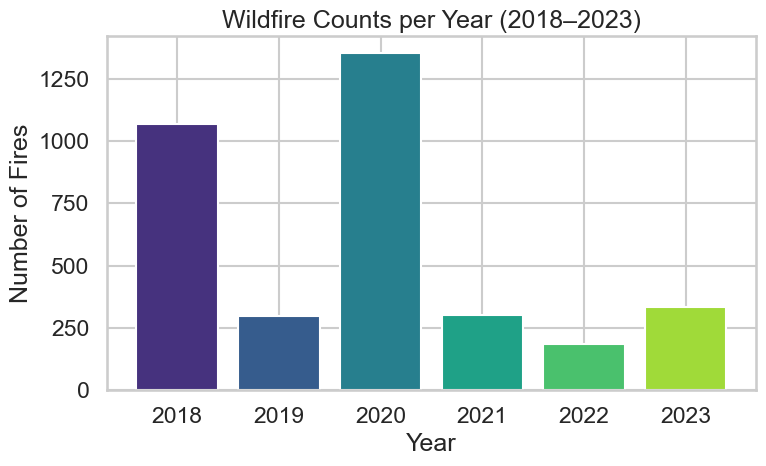

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean theme
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(8, 5))

# Create color gradient
colors = sns.color_palette("viridis", len(fires_per_year))

plt.bar(
    fires_per_year.index.astype(str),
    fires_per_year.values,
    color=colors
)

plt.title("Wildfire Counts per Year (2018–2023)")
plt.xlabel("Year")
plt.ylabel("Number of Fires")

plt.tight_layout()
plt.show()


In [6]:

import geopandas as gpd
from shapely.geometry import Point


In [10]:

df_sample = df.sample(2_000_000, random_state=42)

df_sample = gpd.GeoDataFrame(
    df_sample,
    geometry=gpd.points_from_xy(df_sample.lon, df_sample.lat),
    crs="EPSG:4326"
)


## Step 3: Convert to GeoDataFrame

To perform spatial operations, I convert the dataset into a GeoDataFrame using latitude and longitude coordinates.


In [22]:

df_sample_proj = df_sample.to_crs("EPSG:5070")

In [25]:

road_gdf = gpd.read_file(
    os.path.expanduser("~/Downloads/grid_with_distance_to_road.gpkg")
)

road_gdf_proj = road_gdf.to_crs("EPSG:5070")



## Step 5: Add Distance to Roads

I perform a nearest spatial join to assign each point a distance to the nearest road.

This represents human interaction and accessibility.


In [26]:


df_sample_proj = gpd.sjoin_nearest(
    df_sample_proj,
    road_gdf_proj[["geometry", "distance_to_road_km"]],
    how="left",
    distance_col="road_join_dist"
)



## Step 6: Add Vegetation (Fuel Presence)

Using raster sampling, I extract vegetation data for each location.

This indicates whether burnable fuel is present.


In [30]:

fuel_path = os.path.expanduser(
    "~/Downloads/nlcd_2019_fuel_mask.tif"
)

print(os.path.exists(fuel_path))  # must be True

with rasterio.open(fuel_path) as src:
    coords = list(zip(
        df_sample_proj.geometry.x,
        df_sample_proj.geometry.y
    ))
    df_sample_proj["fuel_present"] = [v[0] for v in src.sample(coords)]


True



## Step 7: Clean and Finalize Features

I clean intermediate columns and standardize feature names.

The final dataset includes:
- Climate variables
- Temporal features
- Road distance
- Vegetation indicators


In [33]:

df_sample_proj["fuel_present"] = df_sample_proj["fuel_present"].where(
    df_sample_proj["fuel_present"].isin([0, 1]),
    0
)


In [35]:


df_sample_proj = df_sample_proj.rename(
    columns={"distance_to_road_km_right": "distance_to_road_km"}
)

df_sample_proj = df_sample_proj.drop(
    columns=["distance_to_road_km_left", "index_right", "road_join_dist", "geometry"],
    errors="ignore"
)


In [36]:

df_sample_proj[["fuel_present", "distance_to_road_km"]].describe()
df_sample_proj["fuel_present"].value_counts(normalize=True)


fuel_present
1    0.737536
0    0.262464
Name: proportion, dtype: float64


## Step 8: Save Final Dataset

The final dataset is saved as:

df_sample_with_spatial_features.parquet

This dataset will be used as input for machine learning models.


In [37]:

df_sample_proj.to_parquet(
    "~/Downloads/df_sample_with_spatial_features.parquet",
    index=False
)



## Conclusion

In this notebook, I combined temporal and spatial features into a single dataset.

This dataset includes:
- Environmental conditions (climate)
- Seasonal patterns
- Vegetation (fuel)
- Human interaction (roads)

This forms the complete feature set used for wildfire risk modeling.
